# Conversion Rate Prediction
## Machine Learning Project

In [73]:
# Importing libraries

import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import f1_score, confusion_matrix
from sklearn.pipeline import Pipeline

from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GridSearchCV
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
)

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt
import plotly.express as px
import plotly.graph_objects as go
import plotly.io as pio
# setting Jedha color palette as default
pio.templates["jedha"] = go.layout.Template(
    layout_colorway=["#4B9AC7", "#4BE8E0", "#9DD4F3", "#97FBF6", "#2A7FAF", "#23B1AB", "#0E3449", "#015955"]
)
pio.templates.default = "jedha"
pio.renderers.default = "notebook"
from IPython.display import display

In [31]:
# Loading the dataset

dataset = pd.read_csv('conversion_data_train.csv')

In [32]:
# Statistiques basiques
print("Nombre de lignes : {}".format(dataset.shape[0]))
print()

print("Aperçu du dataset : ")
display(dataset.head())
print()

print("Statistiques basiques : ")
data_desc = dataset.describe(include='all')
display(data_desc)
print()

print("Pourcentage de valeurs manquantes : ")
display(100*dataset.isnull().sum()/dataset.shape[0])

dataset.info()

Nombre de lignes : 284580

Aperçu du dataset : 


,country,age,new_user,source,total_pages_visited,converted
0,China,22,1,Direct,2,0
1,UK,21,1,Ads,3,0
2,Germany,20,0,Seo,14,1
3,US,23,1,Seo,3,0
4,US,28,1,Direct,3,0



Statistiques basiques : 


,country,age,new_user,source,total_pages_visited,converted
count,284580,284580.000000,284580.000000,284580,284580.000000,284580.000000
unique,4,NaN,NaN,3,NaN,NaN
top,US,NaN,NaN,Seo,NaN,NaN
freq,160124,NaN,NaN,139477,NaN,NaN
mean,NaN,30.564203,0.685452,NaN,4.873252,0.032258
std,NaN,8.266789,0.464336,NaN,3.341995,0.176685
min,NaN,17.000000,0.000000,NaN,1.000000,0.000000
25%,NaN,24.000000,0.000000,NaN,2.000000,0.000000
50%,NaN,30.000000,1.000000,NaN,4.000000,0.000000
75%,NaN,36.000000,1.000000,NaN,7.000000,0.000000



Pourcentage de valeurs manquantes : 


country                0.0
age                    0.0
new_user               0.0
source                 0.0
total_pages_visited    0.0
converted              0.0
dtype: float64

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 284580 entries, 0 to 284579
Data columns (total 6 columns):
 #   Column               Non-Null Count   Dtype 
---  ------               --------------   ----- 
 0   country              284580 non-null  object
 1   age                  284580 non-null  int64 
 2   new_user             284580 non-null  int64 
 3   source               284580 non-null  object
 4   total_pages_visited  284580 non-null  int64 
 5   converted            284580 non-null  int64 
dtypes: int64(4), object(2)
memory usage: 13.0+ MB


In [33]:
# Separate target variable Y from features X
target_name = "converted"

print("Separating labels from features...")
Y = dataset.loc[:, target_name]
X = dataset.drop(target_name, axis=1)  # All columns are kept, except the target
print("...Done.")
print(Y.head())
print()
print(X.head())
print()

Separating labels from features...
...Done.
0    0
1    0
2    1
3    0
4    0
Name: converted, dtype: int64

   country  age  new_user  source  total_pages_visited
0    China   22         1  Direct                    2
1       UK   21         1     Ads                    3
2  Germany   20         0     Seo                   14
3       US   23         1     Seo                    3
4       US   28         1  Direct                    3



In [34]:
# Automatically detect names of numeric/categorical columns
numeric_features = []
categorical_features = []
for i,t in X.dtypes.items():
    if ('float' in str(t)) or ('int' in str(t)) :
        numeric_features.append(i)
    else :
        categorical_features.append(i)

print('Found numeric features ', numeric_features)
print('Found categorical features ', categorical_features)

Found numeric features  ['age', 'new_user', 'total_pages_visited']
Found categorical features  ['country', 'source']


In [35]:
features_list = ['country', 'age', 'new_user', 'source','total_pages_visited'] #'country', 'age', 'new_user', 'source', 
numeric_indices = [0]
categorical_indices = []
target_variable = 'converted'

In [36]:
X = dataset.loc[:, features_list]
Y = dataset.loc[:, target_variable]

print('Explanatory variables : ', X.columns)
print()

Explanatory variables :  Index(['country', 'age', 'new_user', 'source', 'total_pages_visited'], dtype='object')



In [37]:
# Divide dataset Train set & Test set 
print("Dividing into train and test sets...")
X_train, X_test, Y_train, Y_test = train_test_split(X, Y, test_size=0.2, random_state=0)
print("...Done.")
print()

Dividing into train and test sets...
...Done.



In [38]:
# Create pipeline for numeric features
numeric_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='mean')),
    ('scaler', StandardScaler())
])

In [39]:
# Create pipeline for categorical features
categorical_transformer = Pipeline(
    steps=[
        ('encoder', OneHotEncoder(drop='first'))
    ])

In [40]:
#Create pipeline for numeric features
numeric_features = ["age", "new_user","total_pages_visited"]  # Names of numeric columns in X_train/X_test
numeric_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="median"),),  # missing values will be replaced by columns' median
        ("scaler", StandardScaler()),
    ]
)

#Create pipeline for categorical features
categorical_features = ["source","country"]  # Names of categorical columns in X_train/X_test
categorical_transformer = Pipeline(
    steps=[
        ("imputer",SimpleImputer(strategy="most_frequent"),),  # missing values will be replaced by most frequent value
        ("encoder",OneHotEncoder(drop="first"),),  # first column will be dropped to avoid creating correlations between features
    ]
)

#Use ColumnTransformer to make a preprocessor object that describes all the treatments to be done
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features),
    ]
)

In [41]:
#Preprocessing on train set
print(X_train.head())
X_train = preprocessor.fit_transform(X_train)
print(X_train[0:5])

       country  age  new_user  source  total_pages_visited
17050       US   29         1     Seo                    4
260342      US   23         0  Direct                    7
278164      UK   33         1     Seo                   11
268440   China   25         1     Seo                    5
157837      US   40         0     Seo                    1
[[-0.19030813  0.67687527 -0.26094223  0.          1.          0.
   0.          1.        ]
 [-0.9161838  -1.47737706  0.63598611  1.          0.          0.
   0.          1.        ]
 [ 0.29360899  0.67687527  1.83189056  0.          1.          0.
   1.          0.        ]
 [-0.67422524  0.67687527  0.03803388  0.          1.          0.
   0.          0.        ]
 [ 1.14046394 -1.47737706 -1.15787057  0.          1.          0.
   0.          1.        ]]


In [42]:
# Preprocessing on test set
print(X_test.head())
X_test = preprocessor.transform(X_test)
print(X_test[0:5, :])

        country  age  new_user source  total_pages_visited
149371       US   20         1    Ads                    7
221325       US   31         1    Seo                    5
14016        US   28         0    Seo                    4
257982  Germany   25         1    Ads                    4
59983        US   44         0    Ads                    7
[[-1.27912164  0.67687527  0.63598611  0.          0.          0.
   0.          1.        ]
 [ 0.05165043  0.67687527  0.03803388  0.          1.          0.
   0.          1.        ]
 [-0.3112874  -1.47737706 -0.26094223  0.          1.          0.
   0.          1.        ]
 [-0.67422524  0.67687527 -0.26094223  0.          0.          1.
   0.          0.        ]
 [ 1.62438106 -1.47737706  0.63598611  0.          0.          0.
   0.          1.        ]]


In [43]:
# Train model
print("Train model...")
classifier = LogisticRegression() # 
classifier.fit(X_train, Y_train)
print("...Done.")

Train model...
...Done.


In [44]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = classifier.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]



In [45]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = classifier.predict(X_test)
print("...Done")
print(Y_test_pred)

Predictions on test set...
...Done
[0 0 0 ... 0 0 0]


In [46]:
# Scores
print("f1-score on train set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))

f1-score on train set :  0.7650520597555455
f1-score on test set :  0.7572289156626506


In [47]:
# Confusion matrix
print("Confusion matrix on train set : ")
print(confusion_matrix(Y_train, Y_train_pred))
print()
print("Confusion matrix on test set : ")
print(confusion_matrix(Y_test, Y_test_pred))
print()

Confusion matrix on train set : 
[[219480    854]
 [  2260   5070]]

Confusion matrix on test set : 
[[54853   213]
 [  593  1257]]



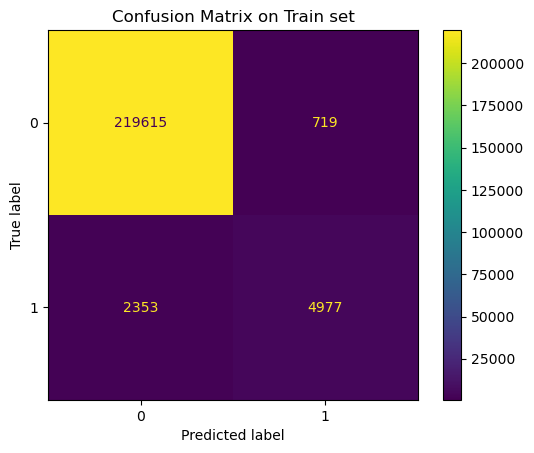

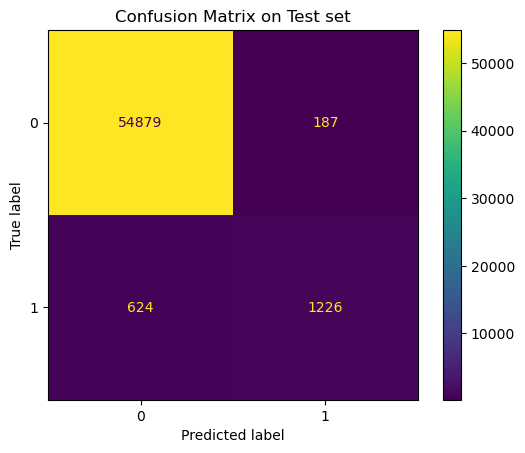

In [65]:
# Visualize confusion matrices
_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Train set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    gridsearch, X_train, Y_train, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

_, ax = plt.subplots()  # Get subplot from matplotlib
ax.set(
    title="Confusion Matrix on Test set"
)  # Set a title that we will add into ConfusionMatrixDisplay
ConfusionMatrixDisplay.from_estimator(
    gridsearch, X_test, Y_test, ax=ax
)  # ConfusionMatrixDisplay from sklearn
plt.show()

In [48]:
# Decision Tree

# Perform grid search
print("Grid search...")
classifier = DecisionTreeClassifier()

# Grid of values to be tested
params = {
    "max_depth": [4, 6, 8, 10],
    "min_samples_leaf": [1, 2, 5],
    "min_samples_split": [2, 4, 8],
}
gridsearch = GridSearchCV(
    classifier, param_grid=params, cv=3
)  # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print("...Done.")
print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)

Grid search...
...Done.
Best hyperparameters :  {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 8}
Best validation accuracy :  0.985272155457165


In [49]:
# Predictions on training set
print("Predictions on training set...")
Y_train_pred = gridsearch.predict(X_train)
print("...Done.")
print(Y_train_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on training set...")
Y_train_proba = gridsearch.predict_proba(X_train)
print("...Done.")
print(Y_train_proba)
print()

Predictions on training set...
...Done.
[0 0 0 ... 0 0 0]

Probabilities on training set...
...Done.
[[9.99903121e-01 9.68791087e-05]
 [9.73021583e-01 2.69784173e-02]
 [9.43396226e-01 5.66037736e-02]
 ...
 [9.99347897e-01 6.52103032e-04]
 [9.99611379e-01 3.88621172e-04]
 [9.99903121e-01 9.68791087e-05]]



In [50]:
# Predictions on test set
print("Predictions on test set...")
Y_test_pred = gridsearch.predict(X_test)
print("...Done.")
print(Y_test_pred)
print()

# It's also possible to get the probabilities estimated by the model:
print("Probabilities on test set...")
Y_test_proba = gridsearch.predict_proba(X_test)
print("...Done.")
print(Y_test_proba)
print()

Predictions on test set...
...Done.
[0 0 0 ... 0 0 0]

Probabilities on test set...
...Done.
[[9.96107738e-01 3.89226218e-03]
 [9.99903121e-01 9.68791087e-05]
 [9.98190864e-01 1.80913614e-03]
 ...
 [9.99903121e-01 9.68791087e-05]
 [9.92095808e-01 7.90419162e-03]
 [9.99737060e-01 2.62940425e-04]]



In [51]:
# Print scores
print("accuracy on training set : ", accuracy_score(Y_train, Y_train_pred))
print("accuracy on test set : ", accuracy_score(Y_test, Y_test_pred))
print()

print("f1-score on training set : ", f1_score(Y_train, Y_train_pred))
print("f1-score on test set : ", f1_score(Y_test, Y_test_pred))
print()

accuracy on training set :  0.986133073301005
accuracy on test set :  0.9850657108721624

f1-score on training set :  0.763254593175853
f1-score on test set :  0.7464200477326969



In [56]:
# Perform grid search
print("Grid search...")
random_forest = RandomForestClassifier()

# Grid of values to be tested
params = {
    'max_depth': [2, 4, 6, 8, 10],
    'min_samples_leaf': [1, 2, 5],
    'min_samples_split': [2, 4, 8],
    'n_estimators': [10, 20, 40, 60, 80, 100]
}
print(params)
gridsearch = GridSearchCV(random_forest, param_grid = params, cv = 3, verbose = 1) # cv : the number of folds to be used for CV
gridsearch.fit(X_train, Y_train)
print("...Done.")


Grid search...
{'max_depth': [2, 4, 6, 8, 10], 'min_samples_leaf': [1, 2, 5], 'min_samples_split': [2, 4, 8], 'n_estimators': [10, 20, 40, 60, 80, 100]}
Fitting 3 folds for each of 270 candidates, totalling 810 fits
...Done.


In [ ]:
scores_dataset = pd.DataFrame(columns=['model', 'accuracy', 'set']) # Initialisation score_dataset

print("Best hyperparameters : ", gridsearch.best_params_)
print("Best validation accuracy : ", gridsearch.best_score_)
print()
print("Accuracy on training set : ", gridsearch.score(X_train, Y_train))
print("Accuracy on test set : ", gridsearch.score(X_test, Y_test))

new_rows = [
    {'model': 'random_forest', 'accuracy': gridsearch.score(X_train, Y_train), 'set': 'train'},
    {'model': 'random_forest', 'accuracy': gridsearch.score(X_test, Y_test), 'set': 'test'}
]

scores_dataset = pd.concat([scores_dataset, pd.DataFrame(new_rows)], ignore_index=True)
scores_dataset

Best hyperparameters :  {'max_depth': 8, 'min_samples_leaf': 5, 'min_samples_split': 2, 'n_estimators': 40}
Best validation accuracy :  0.9860320472274932

Accuracy on training set :  0.986506430529201
Accuracy on test set :  0.9857509311968515


/var/folders/yc/y8r3s7157yx624j371ptst8m0000gn/T/ipykernel_96942/4177008924.py:14: FutureWarning:

The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.



,model,accuracy,set
0,random_forest,0.986506,train
1,random_forest,0.985751,test
